**WEEK-5**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [14]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [16]:
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,3218
Urban_or_Rural,0


In [17]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [20]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [21]:
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0


In [22]:
bins = [5,10,13,16,19]
labels = ["6-10","11-13","14-16","17-18"]
df["Age_Band"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [23]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-16
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,11-13
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,17-18
3,15,Female,1.21,Laptop,False,0.39,Poor Sleep,Urban,14-16
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,11-13


In [24]:
cohort_table = pd.pivot_table(
    df,
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Primary_Device",
    aggfunc="mean"
)

cohort_table

/tmp/ipykernel_526/541133036.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cohort_table = pd.pivot_table(


Primary_Device,Laptop,Smartphone,TV,Tablet
Age_Band,,,,
6-10,NaN,3.921901,3.932201,3.917680
11-13,4.432627,4.537596,4.573583,4.478175
14-16,4.428815,4.521197,4.563499,4.438520
17-18,4.549853,4.540847,4.477568,4.555843


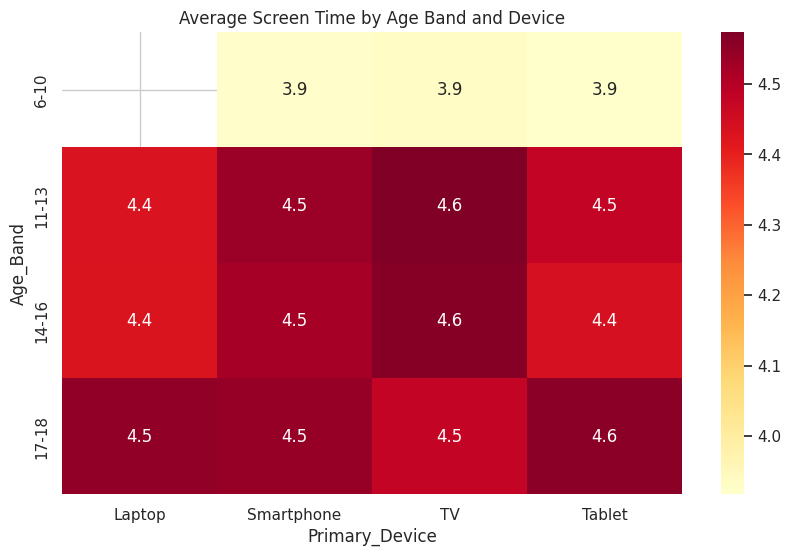

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(cohort_table,
            annot=True,
            cmap="YlOrRd")

plt.title("Average Screen Time by Age Band and Device")
plt.show()

In [26]:
location_device = pd.pivot_table(
    df,
    values="Avg_Daily_Screen_Time_hr",
    index="Urban_or_Rural",
    columns="Primary_Device",
    aggfunc="mean"
)

location_device

Primary_Device,Laptop,Smartphone,TV,Tablet
Urban_or_Rural,,,,
Rural,4.387252,4.397295,4.293812,4.432117
Urban,4.487289,4.385523,4.285161,4.128894


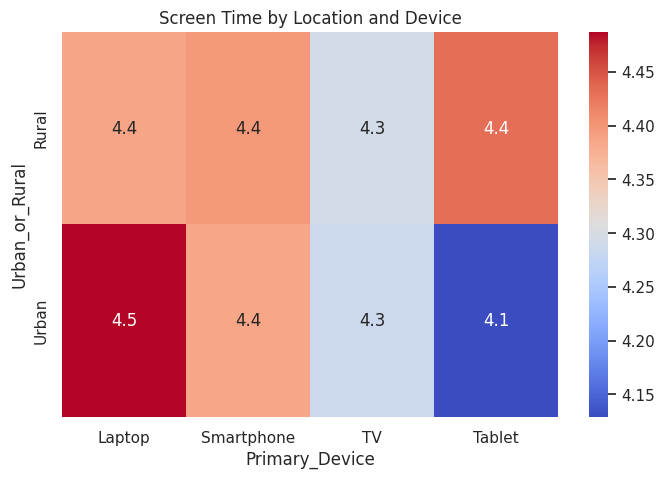

In [27]:
plt.figure(figsize=(8,5))

sns.heatmap(location_device,
            annot=True,
            cmap="coolwarm")

plt.title("Screen Time by Location and Device")
plt.show()

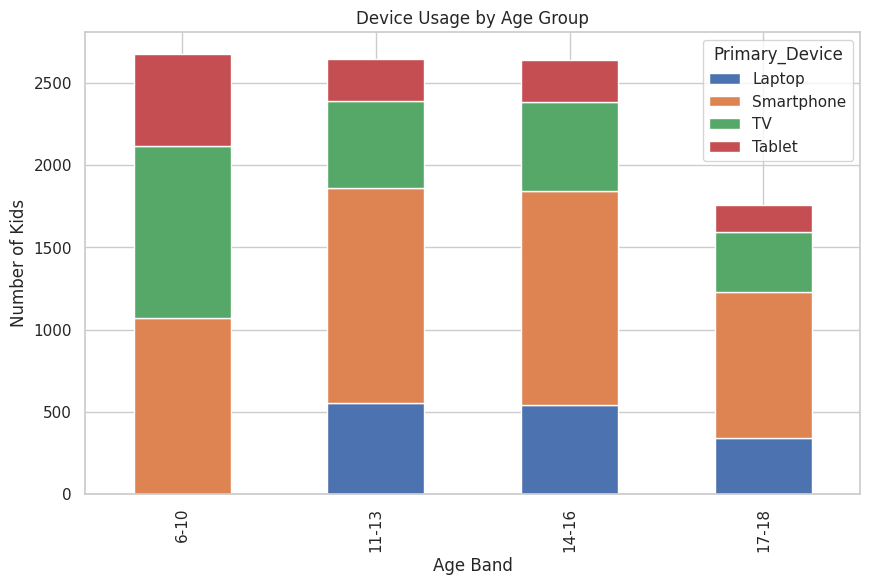

In [28]:
device_age = pd.crosstab(df["Age_Band"], df["Primary_Device"])

device_age.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Device Usage by Age Group")
plt.xlabel("Age Band")
plt.ylabel("Number of Kids")
plt.show()

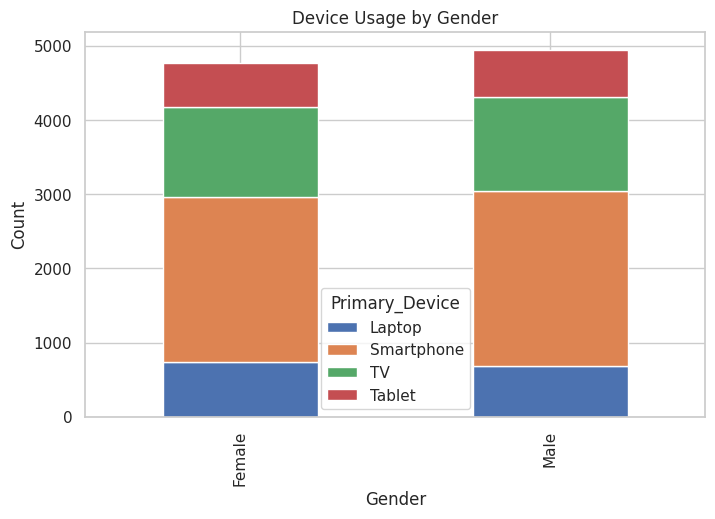

In [29]:
gender_device = pd.crosstab(df["Gender"], df["Primary_Device"])

gender_device.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Device Usage by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [30]:
age_location = pd.pivot_table(
    df,
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Urban_or_Rural",
    aggfunc="mean"
)

age_location

/tmp/ipykernel_526/3289003229.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_location = pd.pivot_table(


Urban_or_Rural,Rural,Urban
Age_Band,,
6-10,3.990426,3.897189
11-13,4.533568,4.510757
14-16,4.511708,4.499360
17-18,4.522080,4.534321


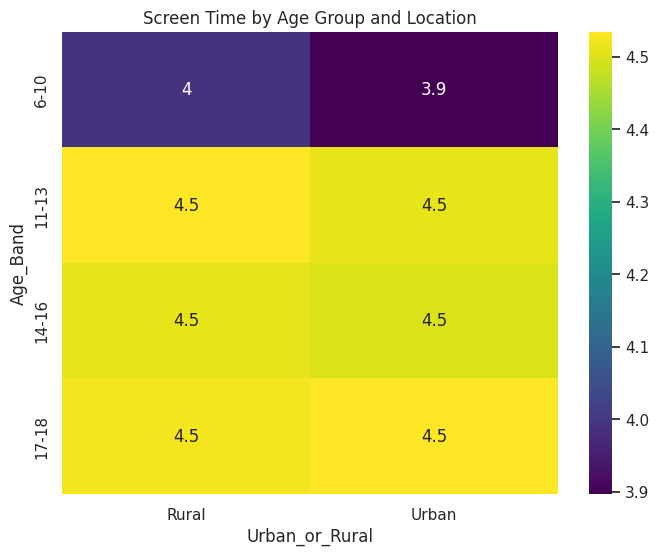

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(age_location,
            annot=True,
            cmap="viridis")

plt.title("Screen Time by Age Group and Location")
plt.show()

**WEEK-6**

In [32]:
df["Health_Impacts"] = df["Health_Impacts"].fillna("None")

In [33]:
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0
Age_Band,0


In [34]:
bins = [5,10,13,16,19]
labels = ["6-10","11-13","14-16","17-18"]
df["Age_Band"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [35]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-16
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,11-13
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,17-18
3,15,Female,1.21,Laptop,False,0.39,Poor Sleep,Urban,14-16
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,11-13


In [36]:
age_pattern = df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean()
age_pattern

/tmp/ipykernel_526/84459321.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_pattern = df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean()


,Avg_Daily_Screen_Time_hr
Age_Band,
6-10,3.925049
11-13,4.517264
14-16,4.503145
17-18,4.530841


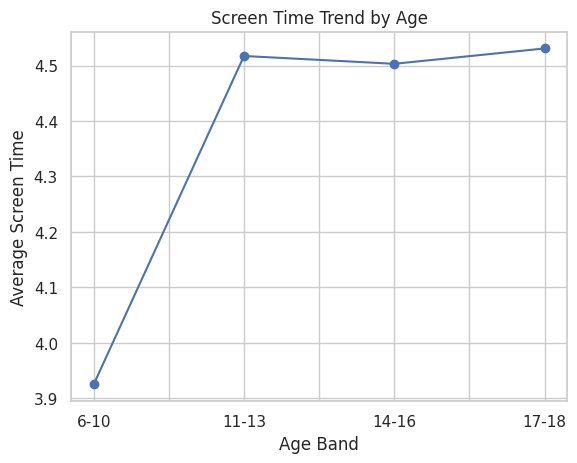

In [37]:
age_pattern.plot(kind="line", marker="o")

plt.title("Screen Time Trend by Age")

plt.xlabel("Age Band")

plt.ylabel("Average Screen Time")

plt.show()

In [38]:
device_pattern = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean()

device_pattern

,Avg_Daily_Screen_Time_hr
Primary_Device,
Laptop,4.459086
Smartphone,4.388925
TV,4.287752
Tablet,4.226005


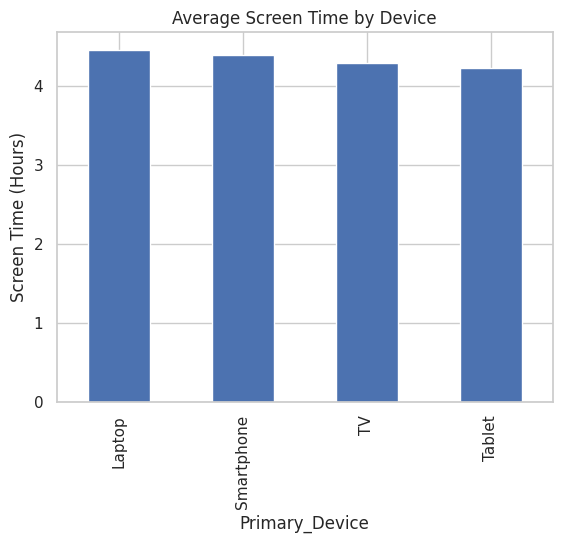

In [39]:
device_pattern.plot(kind="bar")

plt.title("Average Screen Time by Device")

plt.ylabel("Screen Time (Hours)")

plt.show()

In [40]:
gender_pattern = df.groupby("Gender")["Avg_Daily_Screen_Time_hr"].mean()
gender_pattern

,Avg_Daily_Screen_Time_hr
Gender,
Female,4.327021
Male,4.377754


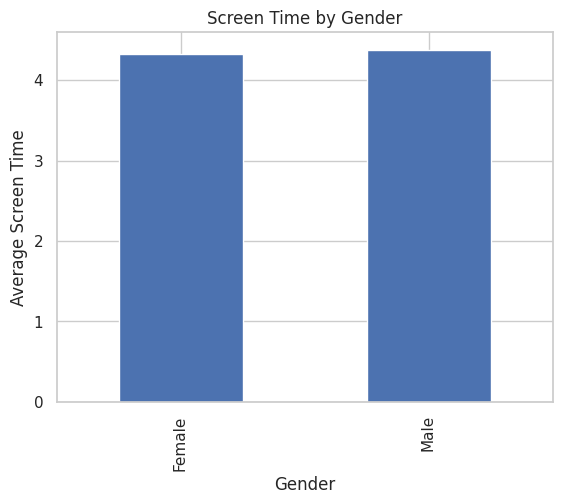

In [41]:
gender_pattern.plot(kind="bar")

plt.title("Screen Time by Gender")

plt.ylabel("Average Screen Time")

plt.show()

In [42]:
location_pattern = df.groupby("Urban_or_Rural")["Avg_Daily_Screen_Time_hr"].mean()

location_pattern

,Avg_Daily_Screen_Time_hr
Urban_or_Rural,
Rural,4.373702
Urban,4.344123


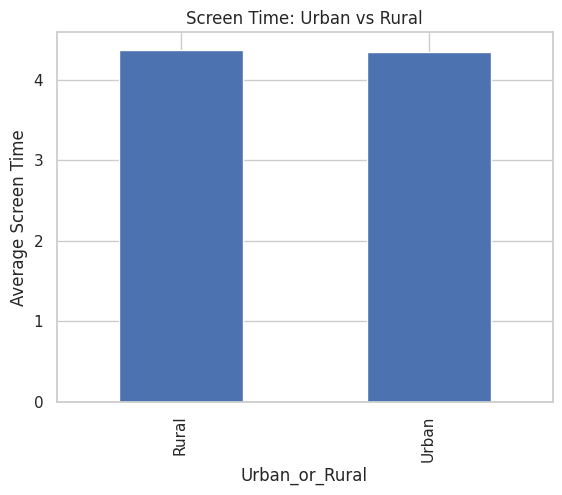

In [43]:
location_pattern.plot(kind="bar")

plt.title("Screen Time: Urban vs Rural")

plt.ylabel("Average Screen Time")

plt.show()

In [44]:
health_pattern = df["Health_Impacts"].value_counts()
health_pattern

,count
Health_Impacts,
Poor Sleep,5486
"Poor Sleep, Eye Strain",979
Eye Strain,644
"Poor Sleep, Anxiety",608
"Poor Sleep, Obesity Risk",452
Anxiety,385
"Poor Sleep, Eye Strain, Anxiety",258
Obesity Risk,252
"Poor Sleep, Eye Strain, Obesity Risk",188


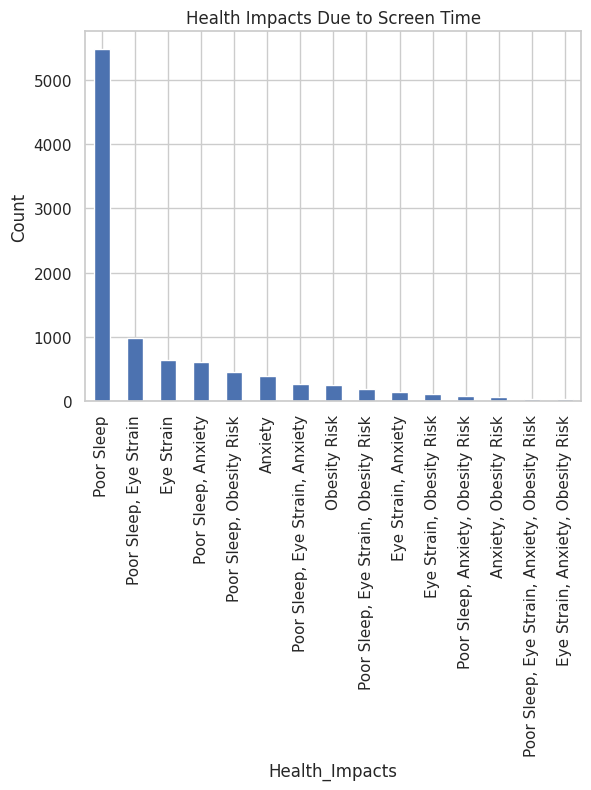

In [45]:
health_pattern.plot(kind="bar")

plt.title("Health Impacts Due to Screen Time")

plt.ylabel("Count")

plt.show()

In [46]:
edu_pattern = df.groupby("Age_Band")["Educational_to_Recreational_Ratio"].mean()
edu_pattern

/tmp/ipykernel_526/742758318.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edu_pattern = df.groupby("Age_Band")["Educational_to_Recreational_Ratio"].mean()


,Educational_to_Recreational_Ratio
Age_Band,
6-10,0.500553
11-13,0.400893
14-16,0.399052
17-18,0.397544


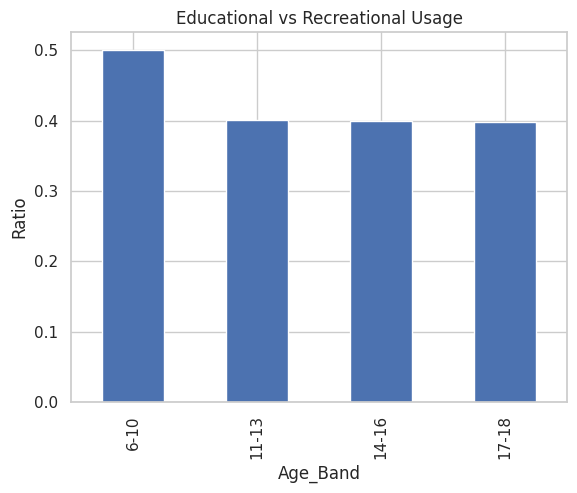

In [47]:
edu_pattern.plot(kind="bar")

plt.title("Educational vs Recreational Usage")

plt.ylabel("Ratio")

plt.show()

/tmp/ipykernel_526/1473468435.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


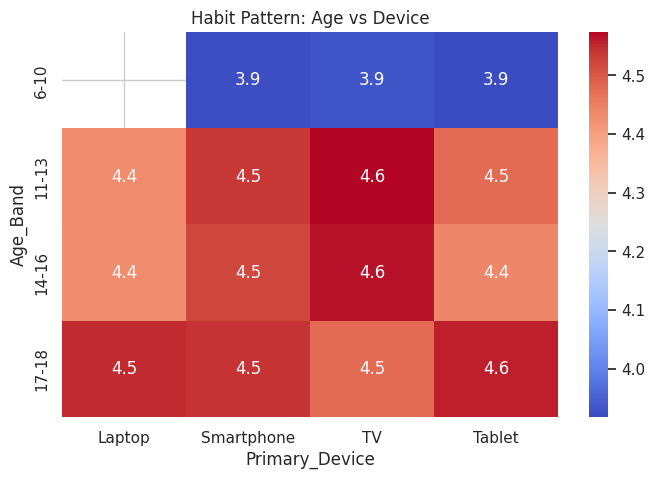

In [48]:
pivot = pd.pivot_table(
    df,
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Primary_Device",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))

sns.heatmap(pivot, annot=True, cmap="coolwarm")

plt.title("Habit Pattern: Age vs Device")

plt.show()